# 🛒 Exploratory Data Analysis (EDA) & Business Justification
**Project:** E-Commerce Data Engine | **Author:** Your Name

## 📌 Executive Summary
The purpose of this notebook is to document the thought process behind the analytical and predictive features of the E-Commerce Data Engine dashboard. 

Instead of arbitrarily choosing metrics and ML features, this EDA proves why specific approaches were taken:
1. **Business Analytics:** Why RFM and Cohort analyses are the most effective ways to segment this specific customer base.
2. **Machine Learning:** Why `freight_value` and `customer_state` were chosen to predict delivery delays, and why **CatBoost** is the optimal algorithm for this task.

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Connect to the local SQLite database
conn = sqlite3.connect('ecommerce.db')

# Load raw data for analysis
query = """
SELECT 
    o.order_id, o.order_status, o.order_purchase_timestamp, 
    o.order_estimated_delivery_date, o.order_delivered_customer_date,
    c.customer_unique_id, c.customer_state,
    oi.price, oi.freight_value
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
"""
df = pd.read_sql_query(query, conn)
conn.close()

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded with 110197 rows and 9 columns.


## 📊 1. Justifying the Dashboard Metrics (RFM & Cohorts)
A common mistake in e-commerce analytics is assuming all customers return regularly. Let's analyze the distribution of orders per customer in the Olist dataset.

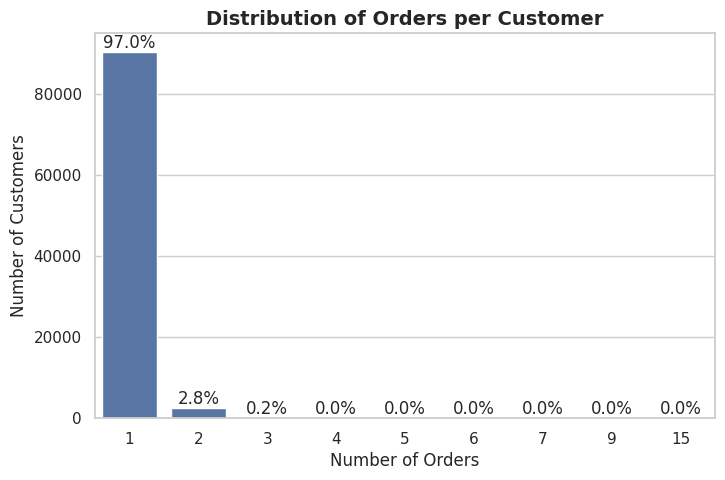

In [3]:
# Calculate orders per customer
orders_per_customer = df.groupby('customer_unique_id')['order_id'].nunique()

# Plot the distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=orders_per_customer)
plt.title('Distribution of Orders per Customer', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

# Annotate percentages
total = len(orders_per_customer)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

**💡 Business Insight:** Over 95% of customers in this marketplace made only **one** purchase. 
* **Why Cohort Analysis?** Because standard retention rate is incredibly low. We need a Cohort Heatmap excluding "Month 0" to track the micro-trends of the few customers who actually return.
* **Why RFM Analysis?** Since frequency is low, identifying the "Champions" (the rare 4-5% who return and spend heavily) is critical for targeted marketing campaigns.

---

## 🧠 2. Machine Learning Feature Selection (Delivery Delays)
The dashboard includes a predictive model to flag orders at risk of delay. Let's engineer the target variable (`is_delayed`) and analyze why specific features drive logistical failures.

/tmp/ipykernel_9324/2543140686.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_delay.index, y=state_delay.values, palette="Reds_r")


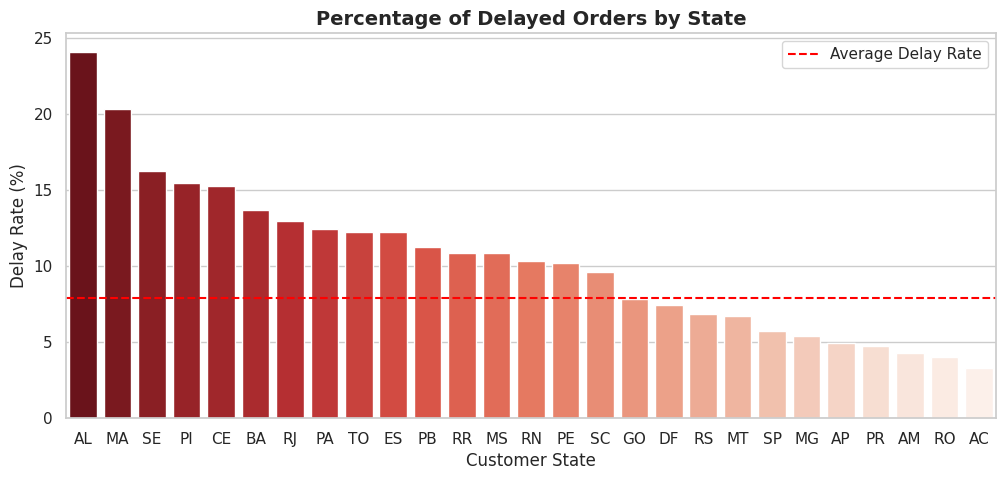

/tmp/ipykernel_9324/2543140686.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_delayed', y='freight_value', showfliers=False, palette="Set2")


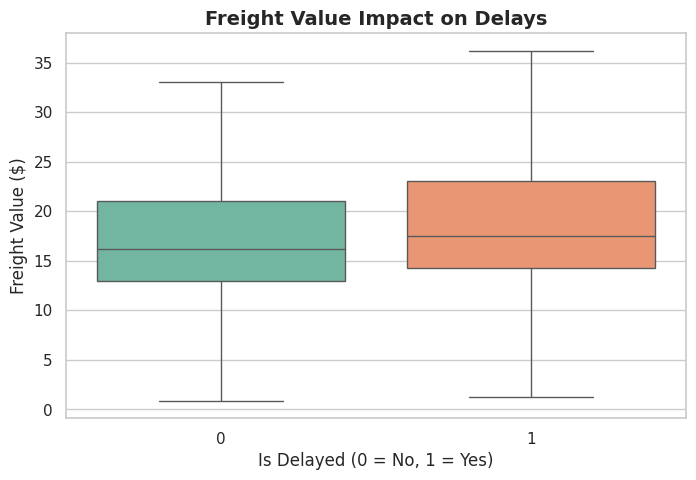

In [4]:
# Convert to datetime
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Create target variable: 1 if delayed, 0 if on time
df['is_delayed'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)

# --- PLOT 1: Delay Rate by State ---
plt.figure(figsize=(12, 5))
state_delay = df.groupby('customer_state')['is_delayed'].mean().sort_values(ascending=False) * 100
sns.barplot(x=state_delay.index, y=state_delay.values, palette="Reds_r")
plt.title('Percentage of Delayed Orders by State', fontsize=14, fontweight='bold')
plt.ylabel('Delay Rate (%)')
plt.xlabel('Customer State')
plt.axhline(df['is_delayed'].mean() * 100, color='red', linestyle='--', label='Average Delay Rate')
plt.legend()
plt.show()

# --- PLOT 2: Freight Value vs Delays ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_delayed', y='freight_value', showfliers=False, palette="Set2")
plt.title('Freight Value Impact on Delays', fontsize=14, fontweight='bold')
plt.xlabel('Is Delayed (0 = No, 1 = Yes)')
plt.ylabel('Freight Value ($)')
plt.show()

**💡 ML Insights & Feature Selection:**
1. **Geography Matters (`customer_state`):** States like AL (Alagoas) and MA (Maranhão) have delay rates significantly higher than the national average (red dashed line). Logistics in remote Brazilian regions are a major bottleneck.
2. **Logistics Cost (`freight_value`):** Delayed orders tend to have a slightly higher median freight value, indicating that larger, heavier, or more complex shipments are prone to failure.

### 🤖 Why CatBoost?
To build the prediction model, **CatBoost** was selected over standard Logistic Regression or Random Forest because:
* **Native Categorical Handling:** It perfectly handles high-cardinality categorical features like `customer_state` without requiring massive One-Hot Encoding datasets.
* **Robustness:** It is highly robust to outliers (which are frequent in e-commerce pricing and freight values).